# Reducing Complexity in Biological Data: Using PCA in Microbiome Studies

*By: Adam Greve Begenhof and Christian Adam Deding Nielsen. With supervision from Jakob Lemvig.*

## Introduction

In bio-engineering and biotechnology you often work with measurements producing a large amount of data. This could be gene expression panels, proteomics, metabolomics, microscopy features, or microbial community profiles (e.g. 16S/amplicon sequencing). These datasets easily contain hundreds to thousands of variables per sample, while the number of samples is often much smaller.

A recurring task is to find hidden structures or descriptors in the data. This could be through
- detecting latent groupings (e.g. patient subtypes, treatment response groups, ecological niches),
- seeing whether samples cluster by environment/geography (e.g. in soil samples from different sites),
- and identifying which variables (genes, taxa, features) drive separation and grouping in data, in order to promote explainability

This is where dimensionality reduction becomes useful. It compresses the data to a few informative coordinates that we can visualize and interpret. In this project you will learn the mathematical ideas behind two common tools:

- **PCA (Principal Component Analysis):** finds directions of maximal variance based on the covariance/correlation structure of the data.
- **PCoA (Principal Coordinate Analysis / classical MDS):** finds low-dimensional coordinates from a chosen **distance** between samples (useful when a domain-specific dissimilarity is more meaningful than raw features).

Lastly, you will put these methods to the test in a real-life example on micro-biomes.
The microbiome is the collection of microorganisms living in a habitat such as the human gut or a soil environment. Microbiome composition is linked to health and disease, and large studies often use microbiome profiles as a "fingerprint" that can separate groups (e.g. healthy vs. disease-associated communities). Similar ideas apply to soil: different locations and conditions (vegetation, nutrients, moisture, human impact) can lead to markedly different microbial communities. Dimensionality reduction makes it feasible to see such patterns by compressing hundreds of taxa/features into a few interpretable axes (sometimes an axis can be interpreted as "high vs. low abundance of certain taxa").

In Sections 1–2 we build intuition and implement PCA from scratch on smaller datasets, and in Sections 3–4 we extend the ideas to PCoA and to real microbiome data.

### Project aims

You should write a cohesive report on PCA and PCoA and their use for biological datasets. You can use the questions in this notebook as guidance, but you don't have to refer to them directly. Questions marked with * are more challenging. In some questions you are asked to prove something and in these cases it may be advantegous to construct specific examples - e.g. if you are asked to show that a matrix $A$ has positive eigenvalues you can construct matrices in SymPy/NumPy with the same structure as $A$ and calculate the eigenvalues. Of course we also encourage you to at least try to do a formal proof. For the report you can choose to focus more on biology by considering various datasets and the usefulness of PCA/PCoA in this context (Section 1 and 4). You can also choose to focus more on the mathematical theory e.g. by considering PCA for complex data and/or proving that PCA and PCoA are in some cases equivalent (Section 2 and 3).

### Motivation check: microbiomes and environmental samples

### Exercise 0.1
> Briefly explain, in your own words, what constitutes a microbiome, and what is typically measured when we "profile" a microbiome?
A microbiome is the collection of microorganisms and their genes present in a certain environment (human gut, soil, etc.). Profiling a microbiome is essentially identifying the species present to then be able to gain insights not only on the taxonomical composition but also on the functional potential of the community. This is often done through sequencing methods that allow us to determine which taxa are present and in what abundance, or through metagenomic sequencing that can provide information on the genes and pathways present in the microbiome.


### Exercise 0.2
> Soil (dirt) samples from different locations can show very different microbiomes. Give two plausible biological/environmental reasons why.
Microbes are highly specialized organisms that inhabit specific ecological niches based on their needs. Even the smallest of deviations in environmental factors like ph, chemical composition, moisture, temperature, vegetation, and human impact can lead to markedly different microbial communities. For example, a soil sample from a forest with rich organic matter and moisture may harbor a diverse community of fungi and bacteria that thrive in such conditions, while a soil sample from an arid desert may have a much less diverse community dominated by extremophiles adapted to dry conditions. Additionally, human activities such as agriculture or pollution can significantly alter the microbial composition of soil by introducing new nutrients or contaminants that select for certain taxa over others. This will lead to different species of microbes dominating in different locations.

### Exercise 0.3
> Suppose you sample soil in Dyrehaven and at another site in Denmark and obtain hundreds of taxa per sample. Explain (conceptually) how PCA/PCoA could help you see whether the sites differ.
PCA and PCoA work by reducing the dimensionality of data while preserving as much of the variance (PCA) or distance (PCoA) as possible. This allows drawing conclusions from the reduced data. For example, if we perform PCA on the microbiome profiles of soil samples from Dyrehaven and another site in Denmark, we can visualize the samples in a 2D or 3D space defined by the principal components. If the samples from the two sites cluster separately in this space, it suggests that there are differences in the microbial communities between the sites. Similarly, PCoA can be used to visualize the distances between samples based on Bray-Curtis dissimilarity, and if samples from different sites cluster apart, it indicates that the microbial communities differ between those sites.



### Preparation

- Eigenvalues, Eigenvectors and Diagonalization: Sections 12.1-12.3 (Mathematics 1a)
- Diagonalizable Matrices, The Spectral Theorem, Projections: Sections 2.7-2.10 (Mathematics 1b)
- Theme 2: Data Matrices and Dimensional Reduction

### Project aims
After completing this project you should be able to:

1. Explain why high-dimensional biological data often benefits from dimensionality reduction.
2. Standardize and center data, form covariance (or correlation) matrices, and compute principal components.
3. Interpret eigenvalues/eigenvectors in terms of variance explained and biological feature contributions.
4. Explain the difference between **feature-based** methods (PCA) and **distance-based** methods (PCoA), and when each is appropriate.
5. Apply PCA/PCoA to biological datasets (Iris flowers and microbiome/soil samples) and discuss the observed clustering patterns.

## Section 1: Warm-up: The data matrix and PCA in NumPy

### Biological warm-up dataset: Iris flowers

Before diving into the general matrix notation, we start with a classic small biological dataset: the **Iris dataset** (R. A. Fisher, 1936).  
Each sample is a flower, described by four measured traits:

- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)

and a species label (*setosa*, *versicolor*, *virginica*).

Even here, with only 4 features, dimensionality reduction is useful: it lets us visualize the data in 2D/3D and see whether species form separable clusters, and which traits drive the separation.

You can read more about the Iris dataset here: [Iris Data](https://archive.ics.uci.edu/dataset/53/iris)

### Exercise 1.0
> (a) What do the variables (features) represent biologically?  
> (b) Why might it be useful to reduce the data from 4 dimensions to 2 dimensions before building a classifier?



(a): the variables repesent measurements of the investigated flowers  
Sepals are the outer parts of a flower that protect the developing bud and often support the petals when the flower blooms.  
Petals are modified leaves that form an inner whorl surrounding the reproductive parts of flowers. They are often brightly coloured or unusually shaped to attract pollinators.

(b): 4 dimensions are not easy to visualize and gain insight from. reduction to 2 dimensions allows for better plotting and easier understanding of the data.

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris['data']              # (150, 4)
y_iris = iris['target']            # (150,)
feature_names = iris['feature_names']
target_names = iris['target_names']

print('X_iris shape:', X_iris.shape)
print('Features:', feature_names)
print('Classes:', target_names)

X_iris shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


Before we begin our exploration of the Iris dataset, we will recap some essential topics from Theme 2 including the data matrix, covariance matrix and essential NumPy functionalities to perform PCA on a small dataset.

We consider an arbitrary data matrix $X \in \mathbb{R}^{n \times d}$ where $n$ denotes the number of data points and $d$ represents the number of features or equivalently the dimensioniality. We wish to standardize our data by subtracting the mean $\mu_1, \mu_2, \dots, \mu_d$ of each column which we can write as

\begin{equation}
\hat{X} = X-c\mu^T,
\end{equation}

where $\pmb{\mu} \in \mathbb{R}^d$ and $\pmb{c} \in \mathbb{R}^n$.

### Exercise 1.1

> Write out the definition of $\pmb{\mu}$ and $\pmb{c}$ such that $\hat{X}$ becomes the standardized data matrix.

$\mu = \Sigma X_{ij}$  
$c = \frac{1}{n} * \textbf{1}$

From $\hat{X}$ we need to compute the covariance matrix 

\begin{equation}
C = \frac
{1}{n-1}\hat{X}^T\hat{X}.
\end{equation}

### Exercise 1.2a

> State the size of the matrix $C$ and show that it admits a spectral decomposition on the form 
> $$
C = Q \Lambda Q^T, 
> $$
> where $Q$ contains the eigenvectors of $C$ and $\Lambda$ the eigenvalues.

C is a matrix with size d x d  

$C^T = \left(\frac{1}{n}\hat{X}^T\hat{X}\right)^T = \frac{1}{n}\hat{X}^T(\hat{X}^T)^T = \frac{1}{n}\hat{X}^T\hat{X} = C \checkmark$


Since $C$ is a $\textbf{real symmetric}$ matrix, the spectral theorem guarantees that:

- $C$ has $d$ real eigenvalues $\lambda_1, \ldots, \lambda_d$
- Its eigenvectors are $\textbf{orthonormal}$, meaning $Q^TQ = I$

So we can write $CQ = Q\Lambda$, where $\Lambda = \text{diag}(\lambda_1, \ldots, \lambda_d)$. Multiplying both sides on the right by $Q^T$:  
$CQQ^T = Q\Lambda Q^T \implies C = Q\Lambda Q^T \checkmark$  
since $QQ^T = I$ (orthonormality of eigenvectors).

### Exercise 1.2b*

> Show that $C$ and $\Lambda$ both are positive semi-definite and hence have nonnegative eigenvalues. If $\hat{X}$ has full rank does $C$ then have any eigenvalues equal to zero?

For any vector $v \in \mathbb{R}^d$, consider the quadratic form:  
$v^T C v = v^T \frac{1}{n}\hat{X}^T\hat{X} v = \frac{1}{n}(\hat{X}v)^T(\hat{X}v) = \frac{1}{n}\|\hat{X}v\|^2 \geq 0$  
since squared norms are always nonnegative. Hence $C$ is positive semi-definite.

Since $C = Q\Lambda Q^T$, for any $v \in \mathbb{R}^d$, let $w = Q^T v$ (which is just a change of basis):  

$v^T C v = v^T Q \Lambda Q^T v = w^T \Lambda w = \sum_{i=1}^d \lambda_i w_i^2 \geq 0$

for all $w$, which requires $\lambda_i \geq 0$ for all $i$. Hence $\Lambda$ is positive semi-definite with nonnegative eigenvalues.


If $\hat{X} \in \mathbb{R}^{n \times d}$ has full rank (i.e.\ rank $d$), then $\hat{X}v = 0$ implies $v = 0$. Therefore:  
$ v^T C v = \frac{1}{n}\|\hat{X}v\|^2 = 0 \implies v = 0$   
meaning $C$ is strictly positive definite, and all eigenvalues are strictly positive, i.e.\ $\lambda_i > 0$ for all $i$. So no, $C$ has no eigenvalues equal to zero.

While less common there is nothing stopping us from considering the case where the data is complex that is $X \in \mathbb{C}^{n \times d}$. In this case we want a Hermitian covarance matix.

### Exercise 1.3

> Recall what being Hermitian means and write the definition of the covariance matrix $C$ for a complex-valued data matrix $X$.  

\begin{equation}
C = \frac
{1}{n-1}\hat{X}^*\hat{X}.
\end{equation}

> Explain what implications it has for the eigenvalues of the covariance matrix that it is complex-valued.

The eigenvalues are the expectations of a square modulus and therefore positive or zero. The determinant is the product of the eigenvalues, the trace is the sum of the eigenvalues.

### Visualization of data

From the spectral decomposition of $C$ we can conclude that it has real eigenvalues and orthogonal eigenvectors which will be useful for projecting the data. Before doing so lets consider how to implement our data techniques in Numpy. We will start by plotting only 2 dimensions of the Iris data, without PCA, coloring by species.

In [70]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
X_full = iris["data"]
y = iris["target"]
feature_names = iris["feature_names"]
target_names = iris["target_names"]

feat_idx = [0, 1]
X = X_full[:, feat_idx]

plt.figure(figsize=(6, 5))
for c in np.unique(y):
    plt.scatter(
        X[y == c, 0], X[y == c, 1],
        s=70, edgecolors="white", linewidth=1.0, alpha=0.85,
        label=target_names[c]
    )

plt.title("Iris: 2D view colored by species", fontsize=14, weight="bold")
plt.xlabel(feature_names[feat_idx[0]])
plt.ylabel(feature_names[feat_idx[1]])
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### Exercise 1.4

> The plot above should not make much sense (except that we might be able to distinguish the setosa species from the others). Let us try to add one more dimension to the data points and create a similar plot in 3d

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
X_full = iris["data"]
y = iris["target"]
feature_names = iris["feature_names"]
target_names = iris["target_names"]

feat_idx = [0, 1, 2]
X = X_full[:, feat_idx]


fig = plt.figure(figsize=(6, 5))

ax = fig.add_subplot(111, projection='3d')

for c in range(3):
    ax.scatter(
        X[y == c, 0], X[y == c, 1], X[y == c, 2],
        s=70, edgecolors="white", linewidth=1.0, alpha=0.85,
        label=target_names[c]
    )

plt.title("Iris: 2D view colored by species", fontsize=14, weight="bold")
ax.set_xlabel(feature_names[feat_idx[0]])
ax.set_ylabel(feature_names[feat_idx[1]])
ax.set_zlabel(feature_names[feat_idx[2]])
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

> Now we are seeing a bit more clustering. But since we can't visualize anymore dimensions, the information from the last dimension in the data is lost in our data analysis. This is where PCA comes in, letting us reduce the data to a visualizable dimensions count.

### Visualization of Complex PCA *

In case it becomes relevant, visualizing complex data can be done in multiple ways:

1. **Real vs. Imaginary scatter plot**
2. **Magnitude vs. Phase plot**

These representations help you interpret the structure of the data in complex space.

In [93]:
"""
Visualize complex PCA projection as real vs imaginary scatter plot.
"""

import matplotlib.pyplot as plt

def plot_complex_pca_projection(X_proj, title="Complex PCA Projection"):
    plt.figure(figsize=(6, 5))
    plt.scatter(
        X_proj.real,
        X_proj.imag,
        s=80,
        edgecolors="white",
        linewidth=1.2,
        alpha=0.85
    )

    plt.title(title, fontsize=14, weight="bold")
    plt.xlabel("Real part of PC1", fontsize=12)
    plt.ylabel("Imaginary part of PC1", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.axis("equal")

    # Clean border style
    for spine in ["top", "right"]:
        plt.gca().spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()

In [94]:
"""
Visualize complex PCA component in polar form (phase vs magnitude).
"""
import numpy as np
import matplotlib.pyplot as plt

def plot_complex_polar(X_proj, pc=0):
    # Compute magnitude and phase of the selected principal component
    magnitude = np.abs(X_proj)
    phase = np.angle(X_proj)

    plt.figure(figsize=(6, 5))
    plt.scatter(
        phase,
        magnitude,
        s=80,
        edgecolors="white",
        linewidth=1.2,
        alpha=0.85
    )

    plt.title(f"Phase–Magnitude of PC{pc+1}", fontsize=14, weight="bold")
    plt.xlabel("Phase (radians)", fontsize=12)
    plt.ylabel("Magnitude", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.5)

    # Clean border style
    for spine in ["top", "right"]:
        plt.gca().spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()

### Exercise 1.5

> Use the following function templates to perform the spectral decomposition from the (unstandardized) data matrix $X$. (Hint: The eigendecomposition for a Hermitian matrix is a bit different in Numpy. Look at the numpy.linalg documentation)

In [74]:
def center_columns(X):
    """Center each column of X
    Input:  X : (n_samples x n_features) Matrix
    Output: Xc: (n_samples x n_features) Matrix with zero-mean columns

    """
    column_average = X.mean(axis= 0)
    return X - column_average

def covariance_matrix(Xc):
    """Sample covariance matrix of centered data Xc.
    Input:  Xc: (n x d) centered
    Output: CC: (d x d) Covariance matrix
    """
    n = Xc.shape[0]
    return 1/(n-1) * Xc.T @ Xc

    # TODO (essential): implement the standard unbiased covariance.

    raise NotImplementedError("Return the sample covariance matrix.")

def eig_sorted_symmetric(C):
    """Eigen-decomposition of a symmetric matrix C.
    Input:  C: Covariance matrix 
    Returns (vals, vecs) with vals sorted descending and vecs columns aligned.
    TODO (essential): create the eigen-decomposition and sort.
    Hints:
      - eigenvects() returns [(eigenval, multiplicity, [basis vectors...]), ...]
      - Build 'vals' as a list and 'vecs' as a Matrix with eigenvectors as columns.
    """
    lamda, Q = np.linalg.eig(C)
    idx = np.argsort(lamda)[::-1]

    lamda = lamda[idx]
    Q = Q[:, idx]

    return lamda, Q
    # TODO: compute and sort eigenpairs
    raise NotImplementedError("Compute sorted eigenpairs for symmetric matrices.")

> Test your implementation by plotting the corresponding eigenspaces for our small test example:

In [75]:
Xc = center_columns(X_full)
C = covariance_matrix(Xc)
Q = eig_sorted_symmetric(C)[1]

q1 = Q[:,0] # The first column
q2 = Q[:,1] # The second column
P = np.outer(q2, q2.T)

# Plotting
t = np.linspace(-5, 5, 20)
fig, ax = plt.subplots()
# ax.plot(t*q1[0], t*q1[1], 'r', label='Line Spanned by q1')
ax.plot(t*q2[0], t*q2[1], 'b', label='Line Spanned by q2')
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.scatter(Xc[:,0], Xc[:,1], label='X_st')
plt.scatter(Xc @ P[:,0], Xc @ P[:,1], label='X_st @ P.T')
plt.title("X_st and X_st @ P.T")
plt.legend()
plt.show()

### Exercise 1.7

> Finish the following function template to create the complete PCA workflow: Given an arbitrary data matrix and subspace dimension $k$ the output should be projected data points contained in a matrix $Z$ and the $k$ eigenvalues $\lambda_1,\dots, \lambda_k$. Plot the projected data points on the same figure as was created in Exercise 3. What can you say about the clusters you see, and can you find an explanation in the data for these clusters i.e. is there a feature that determines these clusters?

In [76]:
def pca_from_cov(X, k: int):
  Xc = center_columns(X)

  C = covariance_matrix(Xc)

  lambdas, Q = eig_sorted_symmetric(C)

  P = Q[:, :k]

  Z = Xc @ P

  return Z, lambdas
  raise NotImplementedError("Assemble PCA from covariance eigen-decomposition.")

In [77]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
X_full = iris["data"]
y = iris["target"]
feature_names = iris["feature_names"]
target_names = iris["target_names"]

Z, lambdas = pca_from_cov(X_full, 2)

plt.figure(figsize=(6, 5))
for c in np.unique(y):
    plt.scatter(
        Z[y == c, 0], Z[y == c, 1],
        s=70, edgecolors="white", linewidth=1.0, alpha=0.85,
        label=target_names[c]
    )

plt.title("Iris: PCA projection colored by species", fontsize=14, weight="bold")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

the clusters as seen above are quite distinct, especially the setosa species. The versicolor and virginica species are more mixed together but still show some separation. The clusters can be explained by the features of the data, particularly petal length and petal width, which are known to be good discriminators between the species in the Iris dataset.
PC1 and PC2 are linear combinations of the original features, and the loadings (eigenvectors) indicate which features contribute most to each principal component. In this case, petal length and petal width likely have high loadings on the first two principal components, driving the separation of the species in the PCA plot.

## Section 2: PCA as an Optimization Problem

In this exercise, you will study PCA from an optimization perspective and connect it to its eigenvalue formulation. You already know that PCA can be computed using spectral decomposition  of the covariance matrix. But what does PCA really do? In this part, we will see that PCA can also be seen as an optimization problem of finding the principal direction that captures as much variance in the data as possible.

### Centering and projecting the data

> Run the cell below to generate some sample 2D data and center it.

In [78]:
import numpy as np
import matplotlib.pyplot as plt

# Create sample 2D data
np.random.seed(0)
X_big = np.random.randn(100, 2) @ np.array([[2, 1], [1, 1]])  # correlated data

# Center the data (subtract column means)
X_big = X_big - X_big.mean(axis=0)

plt.scatter(X_big[:,0], X_big[:,1], alpha=0.7, edgecolors='white', linewidth=1)
plt.axis('equal')
plt.title("Centered Data Points")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Each row of $X$ is a data point $\pmb{x}_i$.
If we project each point onto a direction vector $\pmb{w}$, the projection is given by:

$$
\pmb{z}_i = \pmb{w}^\top \pmb{x}_i
$$

### Exercise 2.1

> Write a NumPy expression below that computes all projections at once (vectorized).

In [79]:
# compute all projections z = X @ w
w = np.array([1, 0])  # try the x1 direction first
z = X_big @ w  # projection onto w

### Measuring variance along a direction

The variance of the projected data along direction $( \pmb{w} )$ is:

$$
\text{Var}(\pmb{z}) = \frac{1}{n} |X \pmb{w}|^2 = \frac{1}{n} \pmb{w}^\top X^\top X \pmb{w}.
$$

Let’s compute it for a few random directions:

In [80]:
def variance_in_direction(X, w):
    w = w / np.linalg.norm(w)
    return (np.linalg.norm(X @ w)**2) / X.shape[0]

for angle in [0, 30, 60, 90]:
    theta = np.deg2rad(angle)
    w = np.array([np.cos(theta), np.sin(theta)])
    print(f"Angle {angle:>2}° → Variance = {variance_in_direction(X_big, w):.3f}")

Angle  0° → Variance = 5.110
Angle 30° → Variance = 6.977
Angle 60° → Variance = 5.435
Angle 90° → Variance = 2.026


### Exercise 2.2

> Try generating several random $w$ vectors, normalize them, and compute the variance each time.
> Which direction (angle) seems to give the largest variance?
> Try plotting the vectors along with the data points as well

In [81]:
for angle in range(0,180,10):
    theta = np.deg2rad(angle)
    w = np.array([np.cos(theta), np.sin(theta)])
    print(f"Angle {angle:>2}° → Variance = {variance_in_direction(X_big, w):.3f}")

Angle  0° → Variance = 5.110
Angle 10° → Variance = 6.059
Angle 20° → Variance = 6.707
Angle 30° → Variance = 6.977
Angle 40° → Variance = 6.835
Angle 50° → Variance = 6.300
Angle 60° → Variance = 5.435
Angle 70° → Variance = 4.345
Angle 80° → Variance = 3.161
Angle 90° → Variance = 2.026
Angle 100° → Variance = 1.078
Angle 110° → Variance = 0.429
Angle 120° → Variance = 0.159
Angle 130° → Variance = 0.301
Angle 140° → Variance = 0.836
Angle 150° → Variance = 1.701
Angle 160° → Variance = 2.791
Angle 170° → Variance = 3.975


the variance seems to be the largest around 30 degrees.

In [82]:
plt.plot([angle for angle in range(0,180,10)], [variance_in_direction(X_big, np.array([np.cos(np.deg2rad(angle)), np.sin(np.deg2rad(angle))])) for angle in range(0,180,10)])
plt.xlabel("Angle (degrees)")
plt.ylabel("Variance")
plt.title("Variance of Data Along Different Directions")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Mini recap: SVD and why it appears in PCA

The singular value decomposition (SVD) factorizes a (centered) data matrix $X\in\mathbb{R}^{n\times d}$ as
$$
X = U\Sigma V^T,
$$
where $U\in\mathbb{R}^{n\times n}$ and $V\in\mathbb{R}^{d\times d}$ are orthogonal, and $\Sigma$ is diagonal with nonnegative singular values $\sigma_1\ge\sigma_2\ge\cdots$.

A key link to PCA is:
$$
X^T X = V\Sigma^2 V^T.
$$
So the right singular vectors (columns of $V$) are the eigenvectors of $X^T X$ (and of the covariance matrix up to scaling), i.e. they give the principal component directions.

In the next exercise you will compute the first principal direction using SVD and compare it to the direction found by the variance-maximization viewpoint.

In [83]:
U, S, Vt = np.linalg.svd(X_big, full_matrices=False)
w_svd = Vt[0]  # first right singular vector (principal direction)
print("First principal direction from SVD:", w_svd)

print("Variance in that direction:", variance_in_direction(X_big, w_svd))

First principal direction from SVD: [-0.85193742 -0.52364361]
Variance in that direction: 6.981964740988469


### Exercise 2.3b

> Compare this direction to the one that gave you the largest variance above. Do they match (up to a sign)?

In [84]:
w_svd = Vt[0]
w_search = np.array([np.cos(np.deg2rad(30)), np.sin(np.deg2rad(30))])

angle_diff = np.degrees(np.arccos(np.abs(np.dot(w_svd, w_search))))
print("Angle difference:", angle_diff)

Angle difference: 1.5769766231239506


the largest variance was around 30 degrees, and the first right singular vector from SVD should also point in that direction (or the opposite direction, which is just a sign change). So yes, they do match!

If we approximate each point $( \pmb{x}_i )$ by projecting it onto $( \pmb{w} )$:

$$
\hat{\pmb{x}}_i = (\pmb{w}^\top \pmb{x}_i)\, \pmb{w},
$$

the total reconstruction error is:

$$
E(\pmb{w}) = \sum_{i=1}^n \|\pmb{x}_i - \hat{\pmb{x}}_i\|_2^2
= \|X\|_F^2 - \|X\pmb{w}\|_2^2
= \|X\|_F^2 - \pmb{w}^\top X^\top X\pmb{w}.
$$

Thus minimizing reconstruction error is equivalent to maximizing the projected variance, since $\|X\|_F^2$ does not depend on $\pmb{w}$, i.e. the expression reduces to:
$$ 
E(\pmb w) = const - n \pmb w^\top X^\top X \pmb{w}
$$

So the two methods of finding Principal Components are actually equal!

### Exercise 2.4*

> Implement a small function to compute ( E(w) ) and verify that smaller error corresponds to higher variance:

In [85]:
# I.e. something like solution below, which of course should be removed for students to complete on their own.
def reconstruction_error(X, w):
   w = w/np.linalg.norm(w)
   x_proj = X @ w[:, np.newaxis] * w[np.newaxis, :]
   return np.linalg.norm(X - x_proj)**2 / X.shape[0]

w_rand = np.random.randn(2)
print("Error (random dir):", reconstruction_error(X_big, w_rand))
print("Error (PCA dir):   ", reconstruction_error(X_big, w_svd))

Error (random dir): 0.15823997460449948
Error (PCA dir):    0.154265073293954


This matches the maximizing direction obtained from the numerical variance search. Thus PCA’s optimization definition
$$ \max_{||w||=1} \pmb w^\top C \pmb w $$
is consistent with the eigenvalue formulation.
<!--endsvar-->

### Exercise 2.6

1. Explain why PCA can be understood as a sequence of optimization problems.  
2. Describe the role of eigenvalues and eigenvectors in this formulation.  
3. Discuss how this formulation extends to complex-valued data.

1. PCA can be understood as a sequence of optimization problems because it seeks to find the principal directions (eigenvectors) that maximize the variance of the projected data. We find each of those eigenvalues by solving an optimization problem that maximizes variance along the direction of the corresponding eigenvector.

2. The eigenvalues represent the amount of variance captured by each principal component (eigenvector). The eigenvector with the largest eigenvalue corresponds to the direction of maximum variance in the data, and subsequent eigenvectors capture decreasing amounts of variance while being orthogonal to the previous ones.

3. In complexed-valued data, the cov matriz becomes hermitian and all eigenvaues are positive or zero. The only difference is that we need to adjust for complex conjucation in the covariance matrix. The eigenvalues will still represent the variance captured by each principal component, and the eigenvectors will still indicate the directions of maximum variance, but we need to ensure that we are working with the correct inner product and covariance definitions for complex data.

## Section 3: Principal Coordinate Analysis

As an alternative to PCA we will consider Principal Coordinate Analysis (PCoA) also called Multidimensional Scaling (MDS) which can be used to reduce the dimension of data based on dissimilarity measures. The method is especially useful in ecology, genetics and social sciences were the difference between data points has higher availability and/or importance compared to direct measurements. 

Again we consider an arbitrary real data matrix $X \in \mathbb{R}^{n \times d}$, but this time we aim to construct a dissimiliarity matrix $D \in \mathbb{R}^{n \times n}$ where the $(i,j)$-element $d_{ij}$ corresponds to the dissimilarity between the $i$-th and $j$-th datapoint. Since we will work with biological data the dissimilarity metric we choose to use is the Bray-Curtis (BC) distance defined as

\begin{equation*}
d_{ij} = \frac{\sum_{k=1}^{d} \left| x_{ik} - x_{jk} \right|}{\sum_{k=1}^{d} \left( x_{ik} + x_{jk} \right)},
\end{equation*}

where $x_{ik}$ denotes the $k$-th element of the $i$-th data point. If $\pmb{x}_i = \pmb{x}_j = \pmb{0}$ we simply define $d_{ij}=0$. The BC distance is typically used in ecology or biology when comparing $n$ different sites containing $d$ different species. If the data only contains nonnegative values the BC distance ranges from 0 to 1 where 0 means perfect similarity meaning each site contains the same number of each species and 1 means perfect dissimiarlity.

### Exercise 3.1

> Show that if $x_{ik} \geq 0$ for $i = 1,\dots,n$ and $k = 1,\dots,d$ then $d_{ij} \in [0,1]$ for all $i,j$.

d are the pairwise distances of the data ponts. since they are all non-negative, the numerator is also non-negative. d must therefore be greater than or equal to zero. it cannot take on a value larger than 1 since the numerator is at most equal to the denominator when $x_{ik}$ and $x_{jk}$ are completely different (i.e. one is zero and the other is positive for all k), which would give $d_{ij} = 1$. Hence, $d_{ij} \in [0,1]$.

### Exercise 3.2

> An alternative way to write the BC distance is 

\begin{equation*}
d_{ij} = 1-\frac{2 \sum_{k=1}^d \min(x_{ik},x_{jk})}{\sum_{k=1}^d (x_{ik}+x_{jk})}
\end{equation*}

> Show that this is equivalent to the above definition.
>
> Hint: Consider the two cases $x_{ik} \geq x_{ij}$ and $x_{ik} < x_{jk}$ for each term in the sum.)

for $x_{ik} \geq x_{jk}$:  
$\min(x_{ik}, x_{jk}) = x_{jk}$, so the term  
$|x_{ik} - x_{jk}| = x_{ik} - x_{jk}$, and the sum becomes:  
$\sum_{k=1}^d |x_{ik} - x_{jk}| = \sum_{k=1}^d (x_{ik} - x_{jk}) = \sum_{k=1}^d (x_{ik} + x_{jk}) - 2\sum_{k=1}^d \min(x_{ik}, x_{jk})$

for $x_{ik} < x_{jk}$:  
$\min(x_{ik}, x_{jk}) = x_{ik}$, so the term  
$|x_{ik} - x_{jk}| = x_{jk} - x_{ik}$, and the sum becomes:  
$\sum_{k=1}^d |x_{ik} - x_{jk}| = \sum_{k=1}^d (x_{jk} - x_{ik}) = \sum_{k=1}^d (x_{ik} + x_{jk}) - 2\sum_{k=1}^d \min(x_{ik}, x_{jk})$

Therefore:  

\begin{equation*}
d_{ij} = \frac{\sum_{k=1}^{d} \left| x_{ik} - x_{jk} \right|}{\sum_{k=1}^{d} \left( x_{ik} + x_{jk} \right)} =   1-\frac{2 \sum_{k=1}^d \min(x_{ik},x_{jk})}{\sum_{k=1}^d (x_{ik}+x_{jk})}
\end{equation*}

### Exercise 3.3*

> From the definition it is clear that $D$ is symmetric, but it turns out that it can have negative eigenvalues. Show that if $D \neq 0$ then $D$ has at least one negative eigenvalue
>
> Hint: Consider the vector $\pmb{v}=\pmb{e}_i-\pmb{e}_j$, where $\pmb{e}_k$ is the unit vector with 1 in the $k$-th element and zero elsewhere).

D is not a Gram Matrix, and thus not positive semi-definite.


Similarly to what we did with PCA we need to center our data before we compute eigenvectors and eigenvalues. However since we are now considering a symmetric matrix we want the mean to be zero in both each column and each row. This is achieved through so-called double centering which outputs the matrix $B$ defined as

\begin{equation*}
B = -\frac{1}{2}H D^{(2)}H
\end{equation*}

where $D^{(2)}$ where is the elementwise squared distance matrix $D^{(2)}_{ij}=d_{ij}^2$ and $H$ is the $n \times n$ centering matrix defined as

\begin{equation*}
H = I - \frac{1}{n} \mathbf{1}\mathbf{1}^T
\end{equation*}

where $\mathbf{1} \in \mathbb{R}^n$ is the vector of all ones.

### Exercise 3.4

> Relate the double centering to what we did in the normilization step before PCA. Confirm that each row and column in $B$ has zero mean.

the double centering is similar to the centering step in PCA, but it is applied to the distance matrix rather than the original data matrix. The centering matrix $H$ ensures that the mean of each row and column of $B$ is zero, which is necessary for the subsequent eigenvalue decomposition to yield meaningful principal coordinates.

### Exercise 3.5

> Show that $B$ admits a spectral decomposition

\begin{equation*}
B = Q \Lambda Q^T.
\end{equation*}

> What can you conclude about the eigenvalues of $B$?

the eigenvalues of be real and can be negative, zero, or positive. The presence of negative eigenvalues indicates that the distance matrix $D$ is not a valid Euclidean distance matrix, which is a common occurrence in PCoA when using certain dissimilarity measures.

### Exercise 3.6

> Create a python function which takes as input a data matrix $X$ and outputs centering matrix $B$. Test your function on the small dataset considered in Exercise 3 by plotting the eigenspace of the two eigenvectors with largest eigenvalues.

In [86]:
def distance_matrix(X):
    n = X.shape[0]
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            D[i, j] = np.linalg.norm(X[i] - X[j])
    return D

In [87]:
def centering_matrix(X):
    n = X.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    B = -0.5 *H @ (distance_matrix(X)**2) @ H
    return B

In [88]:
%matplotlib qt
G = centering_matrix(X_full)
eigenvals, eigenvecs = np.linalg.eig(G)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
X_full = iris["data"]
y = iris["target"]
feature_names = iris["feature_names"]
target_names = iris["target_names"]

plt.figure(figsize=(6, 5))
for c in np.unique(y):
    plt.scatter(
        G[y == c, 0], G[y == c, 1],
        s=70, edgecolors="white", linewidth=1.0, alpha=0.85,
        label=target_names[c]
    )

plt.title("Iris: PCA projection colored by species", fontsize=14, weight="bold")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

With our double centering in place we are ready to compute a low dimensional representation of our data. We choose a dimension $k$ and compute

\begin{equation*}
Z = Q_k \Lambda_k^{1/2}
\end{equation*}

where $\Lambda_k$ contains the $k$ largest eigenvalues of $B$ and the $Q_k$ the corresponding eigenvectors.

### Exercise 3.8

> Create a python function which takes as input a data matrix $X$ and $k$ and outputs the lower dimensional PCoA representation $Z$. Notice that we can have negative eigenvalues in this case so find a way to handle these. Test your implementation on the small dataset and plot the result. Compare with the PCA plot.

In [89]:
def low_dimensional_pcoa(X, k):
    B = centering_matrix(X)
    eigenvals, eigenvecs = np.linalg.eigh(B)

    idx = np.argsort(eigenvals)[::-1]
    eigenvals = eigenvals[idx]
    eigenvecs = eigenvecs[:, idx]

    positive_indices = np.where(eigenvals > 0)[0][:k]
    return eigenvecs[:, positive_indices] * np.sqrt(eigenvals[positive_indices])

Z = low_dimensional_pcoa(X_full, 2)
plt.figure(figsize=(6, 5))
for c in np.unique(y):
    plt.scatter(
        Z[y == c, 0], Z[y == c, 1],
        s=70, edgecolors="white", linewidth=1.0, alpha=0.85,
        label=target_names[c]
    )
plt.title("Iris: PCoA projection colored by species", fontsize=14, weight="bold")
plt.xlabel("PCo1") 
plt.ylabel("PCo2")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

<!--endsvar-->

The PCA plot found the linear combinations of the original features that capture the most variance, while the PCoA plot found a low-dimensional representation based on the pairwise distances between samples. Depending on the structure of the data and the chosen distance metric, the two plots may show similar clustering patterns or they may differ significantly. The PCA plot may show more clear separation if the variance is dominated by a few features, while the PCoA plot may reveal different groupings based on overall dissimilarity.

## Section 4: Working with real microbiome data

With the fundamentals in place it is time to test our methods on a real dataset. We consider the biological genum data stored in the attached csv file. The raw data stores site counts of various genera of bacteria in 13 different types of soil samples: 3 of type pristine grass (P5,P8 and P9), 3 of wheat type (S3, S7 and S9) along with corn (S1), rye (S4), barley (S5), rapeseed (S6), grass seed (S8) and Lucerne (S10) with five replicates for each site. The dataset is high dimensional and our developed tools (PCA and PCoA) will be used to provide low dimensional visualizations. These can ultimately be used to extract useful information regarding the bioactivity at the species level.

### Exercise 4.1

> Load the csv file using the pandas library and convert it into a numpy array (matrix) of suitable size. What is the number of data points $n$ and dimension $d$ of each data point? What does $d$ represent?

> Hint: When reading a csv file using pandas you may need to change the encoding and the delimiter.

In [90]:
import pandas as pd

data = pd.read_csv("ALL_16S.csv", encoding="latin-1", delimiter=";")
X_full = data.iloc[:, 1:].values.astype(float)

there are 65 data points and 379 dimensions. each dimension represents the count of a specific genus of microbe in the sample.

<!--endsvar-->

### Exercise 4.2

> Based on the article: [Identification and Differentiation of Pseudomonas Species in Field Samples Using an rpoD Amplicon Sequencing Methodology](https://pubmed.ncbi.nlm.nih.gov/34342531/) and other sources you find online provide a short description of the relevance of profilling bacteria such as the ones contained in the provided dataset. Specifically you should describe the usefulness of various genera such as Pseudomonas for biotechnical purposes and also mention why it can be important to profile them on various taxonomic levels (e.g genera or species level compared to family level). Also mention how PCA/PCoA can help with this profiling.

When profiling a microbiome and thereby the microbial community composition, we can identify the present species in the given sample. This gives inisght into the functionality and interactions between microbial species.
For Pseudomonas specifically, we can see from the paper that species of the genus have a large variety of effects on plants - both symbiotic and pathogenic. Profiling the genus and figuring out, which specific species are correlated with the positive effects such as improved plant growth and disease resistance is therefore important for various biotechnical and agricultural purposes. PCA and PCoA as methods can help by reducing the dimensionality of the data to confidently draw conclusions about functionality of the different species and allow for visibly understandable data. 

### Excerise 4.3

> Discuss why the Bray-Curtis distance function is appropriate to use for this dataset. Do you need to normalize before running PCoA?

The Bray Curtis distance function is appropriate to use for this dataset since we have the same amount of entries for each data point (size n = 65).
we will not need to normalize before running PCoA since the Bray-Curtis distance is already normalized by the sum of the counts, which accounts for differences in sequencing depth or total counts across samples.

### Exercise 4.4

> Perform PCA and PCoA with $k=1,2,3$ and visualize the results in a suitable manner with different colors and labels for the different sites. Describe the differences you see between the two methods and compare with the following figure* form the article 

>*Note that in the paper the authors used so-called non-metric multidimensional scaling (NMDS) which is a generalization of PCoA well suited for handling complex dataset and unveiling relative relationships in nonlinear data. While the method is different you should be able to produce a somewhat similar plot.

![](nmds_plot.jpg)

In [91]:
treatments = data["Treatment"].values
Z = low_dimensional_pcoa(X_full, 3)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

for c in np.unique(treatments):
    mask = treatments == c
    ax.scatter(
        Z[mask, 0], Z[mask, 1], Z[mask, 2],
        s=70, edgecolors="white", linewidth=1.0, alpha=0.85,
        label=c
    )

ax.set_title("16S Data: PCoA projection colored by treatment", fontsize=14, weight="bold")
ax.set_xlabel("PCo1")
ax.set_ylabel("PCo2")
ax.set_zlabel("PCo3")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend(loc="best", fontsize="small", ncol=2)
plt.tight_layout()
plt.show()


In [92]:
# PCA Visualization
Xc = X_full - X_full.mean(axis=0)
C = 1/(X_full.shape[0] - 1) * Xc.T @ Xc
eigenvals, eigenvecs = np.linalg.eigh(C)
idx = np.argsort(eigenvals)[::-1]
eigenvals = eigenvals[idx]
eigenvecs = eigenvecs[:, idx]
Z = Xc @ eigenvecs[:, :3]

import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(6, 5))
ax = plt.subplot(111, projection="3d")
for c in np.unique(treatments):
    ax.scatter(
        Z[treatments == c, 0], Z[treatments == c, 1], Z[treatments ==c, 2],
        s=70, edgecolors="white", linewidth=1.0, alpha=0.85,
        label=c
    )

plt.title("PCA projection colored by treatment", fontsize=14, weight="bold")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

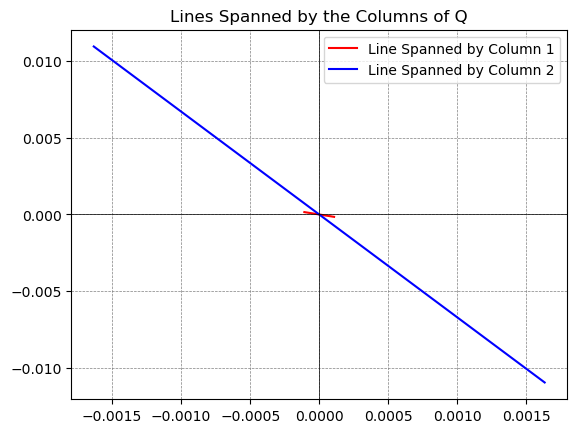

In [44]:
q1 = eigenvecs[0] # The first column
q2 = eigenvecs[1] # The second column

# Define a range for t, which will be used to extend the lines
t = np.linspace(-10, 10, 200)

# Plotting
fig, ax = plt.subplots()
# For each vector, plot a line that it spans
ax.plot(t*q1[0], t*q1[1], 'r', label='Line Spanned by Column 1')
ax.plot(t*q2[0], t*q2[1], 'b', label='Line Spanned by Column 2')

# Adjust the plot limits and style
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.grid(color = 'gray', linestyle = '--', linewidth = 0.5)
plt.legend()
plt.title('Lines Spanned by the Columns of Q')

# Display the plot
plt.show()

### Exercise 4.5

> Plot the eigenvalues for the PCA and PCoA results in a suitable manner. How high $k$ does it make sense to use?

we should refrain from using a k value of higher than 3 since the first three eigenvalues capture the majority of the variance and thereby the most meaninful structure in the data. using a higher k would also reintroduce the issue of visualizing the data and drawing conclusions from it.

### Exercise 4.6

> Discuss possible biological explanations for the above results. Your discussion should mention reasons for isolated clusters in the low-dimensional representation. It might be useful to consider the other figures in the article for more information on the data. Remember to distinguish between the recording methods in the article, only the figures where 16S is investigated are relevant.

in the pcoa plot, there is one sample that clusters significantly away from the others. this could be due to e.g. a unique microbial composition in that sample. The other sample cluster closer togerther, suggesting similarities in their microbial communities. The Pca plot shows a similar pattern with one sample located further away from the rest.

PCA tells us whta features (genera) are driving the separation of the samples, while PCoA tells us about the overall dissimilarity between the samples. The isolated cluster in both plots could indicate a sample with a distinct microbial community, which could be due to various factors such as soil type, plant type, or environmental conditions. Further analysis of the specific genera present in that sample compared to the others could provide insights into the biological reasons for this separation.